[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/seap-udea/fargopy/blob/main/examples/fargopy-tutorial-control.ipynb)

<p align="left"><img src="https://github.com/seap-udea/fargopy/raw/refactor/docs/fargopy_logo.webp" width="300" /></p>

# Tutorial: control FARGO3D from Python

In [1]:
try:
    from google.colab import drive
    %pip install -Uq git+https://github.com/seap-udea/fargopy
except ImportError:
    print("Not running in Colab, skipping installation")
    %load_ext autoreload
    %autoreload 2
!mkdir -p ./gallery/


Not running in Colab, skipping installation


### What's in this notebook

In this notebook we illustrate in depth **how to control `FARGO3D` (setup, compile and run)** in `FARGOpy`.

### Before starting

If you are in `Google Colab`, install the latest version of the package:

For this tutorial you will need the following external modules and tools:

In [2]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd


Your configuration file version '1.0.8' it is different than the installed version of FARGOpy '1.0.9'
Running FARGOpy version 1.0.9


### Let's `FARGOpy`

We call *control* the possibility to setup and run `FARGO3D` from an `IPython/Jupyter` session.

You should start by initializing fargopy, namely getting FARGO3D:

In [3]:
fp.initialize('download', force=True)

Directory '/Users/jzuluaga/fargo3d/' already exists. Removing it...


Cloning into 'fargo3d'...


	FARGO3D downloaded to /Users/jzuluaga/fargo3d/
Header file for FARGO3D found in the fargo directory /Users/jzuluaga/fargo3d/


First we need to create an empty `Simulation` object:

In [4]:
sim = fp.Simulation()

Your simulation is now connected with '/Users/jzuluaga/fargo3d/'


You can verify that the simulation is clean by printing the object:

In [5]:
print(sim)

Simulation information:
    FARGO3D directory: /Users/jzuluaga/fargo3d/
        Outputs: /Users/jzuluaga/fargo3d/outputs
        Setups: /Users/jzuluaga/fargo3d/setups
    Units:
        G = 1 UL^3/(UM UT^2)
        UL, UM, UT = 14959800000000.0 m, 1.9891e+33 kg, 5022421.439871778 s
        UE = 5271139.687948494 J/m^3
        UV = 2978603.086001067 m/s
        URHO = 5.941269533317109e-07 kg/m^3
        USIGMA = 8888020.39645173 kg/m^2
    Setup: None
    Setup directory: None
    Output directory: None



Next thing to do is to select the `setup` you want to control. You can obtain a list of setups using:

In [6]:
fp.Simulation.list_setups()

Setup 'binary' in '/Users/jzuluaga/fargo3d/setups/binary'
Setup 'fargo' in '/Users/jzuluaga/fargo3d/setups/fargo'
Setup 'fargo_multifluid' in '/Users/jzuluaga/fargo3d/setups/fargo_multifluid'
Setup 'fargo_nu' in '/Users/jzuluaga/fargo3d/setups/fargo_nu'
Setup 'mri' in '/Users/jzuluaga/fargo3d/setups/mri'
Setup 'otvortex' in '/Users/jzuluaga/fargo3d/setups/otvortex'
Setup 'p3diso' in '/Users/jzuluaga/fargo3d/setups/p3diso'
Setup 'p3disof' in '/Users/jzuluaga/fargo3d/setups/p3disof'
Setup 'sod1d' in '/Users/jzuluaga/fargo3d/setups/sod1d'



Choose a setup:

In [36]:
sim.set_setup('p3diso')

Now your simulation setup is at '/Users/jzuluaga/fargo3d/setups/p3diso'


'p3diso'

Compile the `FARGO3D` binary to run the simulation:

In [37]:
sim.compile(parallel=0,gpu=0)

Compiling fargo3d-SETUP_p3diso-PARALLEL_0-GPU_0...
Succesful compilation of FARGO3D binary fargo3d-SETUP_p3diso-PARALLEL_0-GPU_0


Run the simulation:

In [38]:
sim.run(cleanrun=True,unlock=True)

No output directory /Users/jzuluaga/fargo3d/outputs/p3diso yet created.
Running asynchronously (test = False):  ./fargo3d-SETUP_p3diso-PARALLEL_0-GPU_0 -m -t setups/p3diso/p3diso.par
Now you are connected with output directory '/Users/jzuluaga/fargo3d/outputs/p3diso'
Found a variables.par file in '/Users/jzuluaga/fargo3d/outputs/p3diso', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 100 [[0, np.float64(-3.1101767270538954)], [-1, np.float64(3.1101767270538954)]]
	Variable r: 80 [[0, np.float64(0.605625)], [-1, np.float64(1.494375)]]
	Variable theta: 20 [[0, np.float64(1.4245463267948968)], [-1, np.float64(1.5670463267948964)]]
Number of snapshots in output directory: 1
Planets found in summary.dat:
  Name: SuperEarth, Initial pos: [1.0, 1e-05, 0.0], Mass: 1e-05


Or check the progress of the simulation:

In [39]:
sim.status('progress')


################################################################################

Progress of the simulation (interrupt by pressing the stop button):
1:OUTPUTS 0 at date t = 0.000000 OK [output pace = 0.1 secs]
2:OUTPUTS 1 at date t = 3.141593 OK [output pace = 0.1 secs]
3:OUTPUTS 2 at date t = 6.283185 OK [output pace = 2.1 secs]
4:OUTPUTS 3 at date t = 9.424778 OK [output pace = 4.3 secs]
5:OUTPUTS 4 at date t = 12.566371 OK [output pace = 4.3 secs]

Other status modes: 'isrunning', 'logfile', 'outputs', 'progress', 'summary'


You may stop the simulation at any time using:

In [40]:
sim.stop()

The process is locked by PID 40033
Stopping FARGO3D process (pid = 40033)


Check the status of the simulation using:

In [41]:
sim.status('isrunning summary progress')


################################################################################
Running status of the process:
	The process is stopped.

################################################################################
Summary:
The simulation has been ran for 5 time-steps (including the initial one).

################################################################################

Progress of the simulation (interrupt by pressing the stop button):
The simulation is not running anymore

Other status modes: 'isrunning', 'logfile', 'outputs', 'progress', 'summary'


Once stopped you may resume the simulation at any snapshot or at the latest resumable snapshot:

In [42]:
sim.resume()

Resuming from snapshot 3...
Running asynchronously (test = False):  ./fargo3d-SETUP_p3diso-PARALLEL_0-GPU_0 -m -t -S 3 -t setups/p3diso/p3diso.par
Now you are connected with output directory '/Users/jzuluaga/fargo3d/outputs/p3diso'
Found a variables.par file in '/Users/jzuluaga/fargo3d/outputs/p3diso', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 100 [[0, np.float64(-3.1101767270538954)], [-1, np.float64(3.1101767270538954)]]
	Variable r: 80 [[0, np.float64(0.605625)], [-1, np.float64(1.494375)]]
	Variable theta: 20 [[0, np.float64(1.4245463267948968)], [-1, np.float64(1.5670463267948964)]]
Number of snapshots in output directory: 5
Planets found in summary.dat:
  Name: SuperEarth, Initial pos: [1.0, 1e-05, 0.0], Mass: 1e-05


Once the simulation has been completed you will notice by ran:

In [43]:
sim.stop()

The process is locked by PID 40409
Stopping FARGO3D process (pid = 40409)


In [44]:
sim = fp.Simulation(setup='p3diso',load=True)

Loading simulation from '/Users/jzuluaga/fargo3d/setups/p3diso/fargopy_simulation.json'
Your simulation is now connected with '/Users/jzuluaga/fargo3d/'
Now your simulation setup is at '/Users/jzuluaga/fargo3d/setups/p3diso'
Now you are connected with output directory '/Users/jzuluaga/fargo3d/outputs/p3diso'
Found a variables.par file in '/Users/jzuluaga/fargo3d/outputs/p3diso', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 100 [[0, np.float64(-3.1101767270538954)], [-1, np.float64(3.1101767270538954)]]
	Variable r: 80 [[0, np.float64(0.605625)], [-1, np.float64(1.494375)]]
	Variable theta: 20 [[0, np.float64(1.4245463267948968)], [-1, np.float64(1.5670463267948964)]]
Number of snapshots in output directory: 5
Planets found in summary.dat:
  Name: SuperEarth, Initial pos: [1.0, 1e-05, 0.0], Mass: 1e-05


Let's read the field we want to animate, eg. the gas density. It is important to notice that we will animate the field in a slice corresponding to $z=0$:

In [56]:
fields_spherical = sim.load_field(
    fields='gasdens',
    snapshot=[1, sim.nsnaps-1],
    coords='spherical',
    slice='theta=1.56'
)

fields_cartesian = sim.load_field(
    fields='gasdens',
    snapshot=[1, sim.nsnaps-1],
    coords='cartesian',
    slice='theta=1.56'
)

And the plot can be done using:

In [60]:
snapshot = 1

phi = fields_spherical.var1_mesh[snapshot]
r = fields_spherical.var2_mesh[snapshot]

x = fields_cartesian.var1_mesh[snapshot]
y = fields_cartesian.var2_mesh[snapshot]

gasdens_plane = fields_cartesian.gasdens_mesh[snapshot]

In [62]:
Now we can plot the result:

SyntaxError: invalid syntax (1739733494.py, line 1)

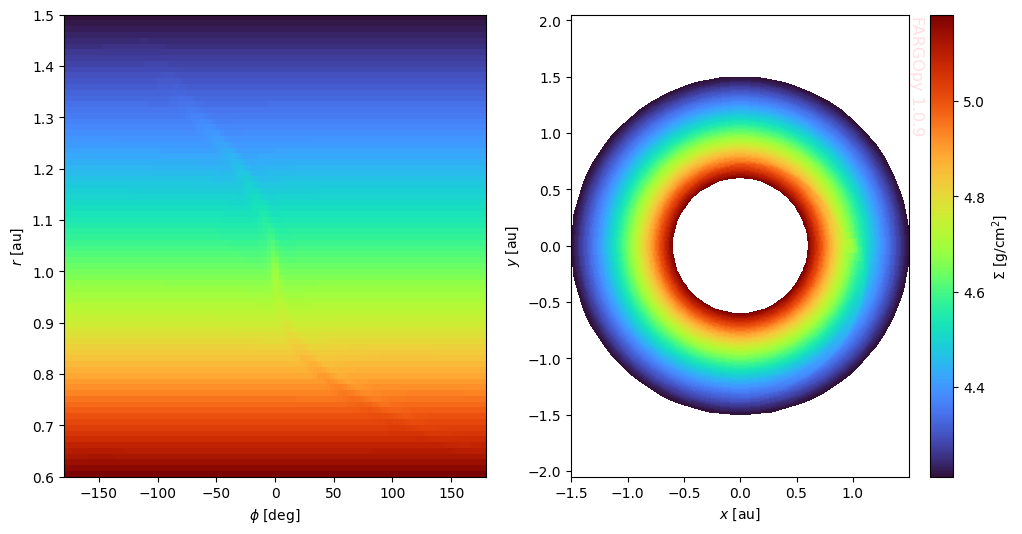

In [68]:
plt.close('all')
fig,axs = plt.subplots(1,2,figsize=(12,6))
cmap = 'turbo'

ax = axs[0]
ax.pcolormesh(phi*fp.RAD,r*sim.UL/fp.AU,np.log10(gasdens_plane*sim.USIGMA),cmap=cmap)
ax.set_xlabel('$\phi$ [deg]')
ax.set_ylabel('$r$ [au]')

ax = axs[1]
c = ax.pcolormesh(x*sim.UL/fp.AU,y*sim.UL/fp.AU,np.log10(gasdens_plane*sim.USIGMA),cmap=cmap)
ax.set_xlabel('$x$ [au]')
ax.set_ylabel('$y$ [au]')
ax.axis('equal')
fp.Plot.fargopy_mark(ax, frac=1/4)

axc = fig.colorbar(c)
axc.set_label("$\Sigma$ [g/cm$^2$]")
plt.savefig('gallery/fargopy-tutorial-animations_0.png') # Save figure


---
*Powered by fargopy*. For more examples see [fargopy GitHub repo](https://github.com/seap-udea/fargopy/tree/main/examples). 

Jorge I. Zuluaga, Alejandro Murillo-González and Matías Montesinos © 2023-present
